# NuAncestor Telescope Visibility: Requirements Comparison

This notebook compares telescope visibility results obtained from six FreeFlyer simulations. Three semi-major axes are considered: 19,300 km, 23,200 km, and 28,750 km. For each orbit, the results obtained using the original telescope requirements are compared with those obtained using relaxed requirements.

The original requirements use a minimum elevation of 36° and a maximum elevation tracking speed of 10 arcsec/s. The relaxed requirements use a minimum elevation of 30° and a maximum elevation tracking speed of 15 arcsec/s.

Version 07/2026 by Pedro de S. C. Leonardo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display

In [2]:
# Main folder containing the six simulation folders
BASE = Path("All_Results/RelaxedParamsCompared/30_days/")

# Settings to change !!
DAYS = 30
SAVE_FIGURES = False
SHOW_REQUIREMENTS = False

In [3]:
stations = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
colors = ["r", "blueviolet", "cyan", "orange", "lime"]

# Each case defines one semi-major axis and its old/relaxed simulation folders
cases = [
    {"name": "28750 km", "a": 28750,
     "folders": {"Old Reqs": "Results_a28750_oldParams", "Relaxed Reqs": "Results_a28750_newParams"}},

    {"name": "23200 km", "a": 23200,
     "folders": {"Old Reqs": "Results_a23200_oldParams", "Relaxed Reqs": "Results_a23200_newParams"}},

    {"name": "19300 km", "a": 19300,
     "folders": {"Old Reqs": "Results_a19300_oldParams", "Relaxed Reqs": "Results_a19300_newParams"}}]


# Read one FreeFlyer results file
def read_result(folder, filename):
    path = BASE / folder / filename
    return pd.read_csv(path, skiprows=3, sep=r"\s+").to_numpy(dtype=float)

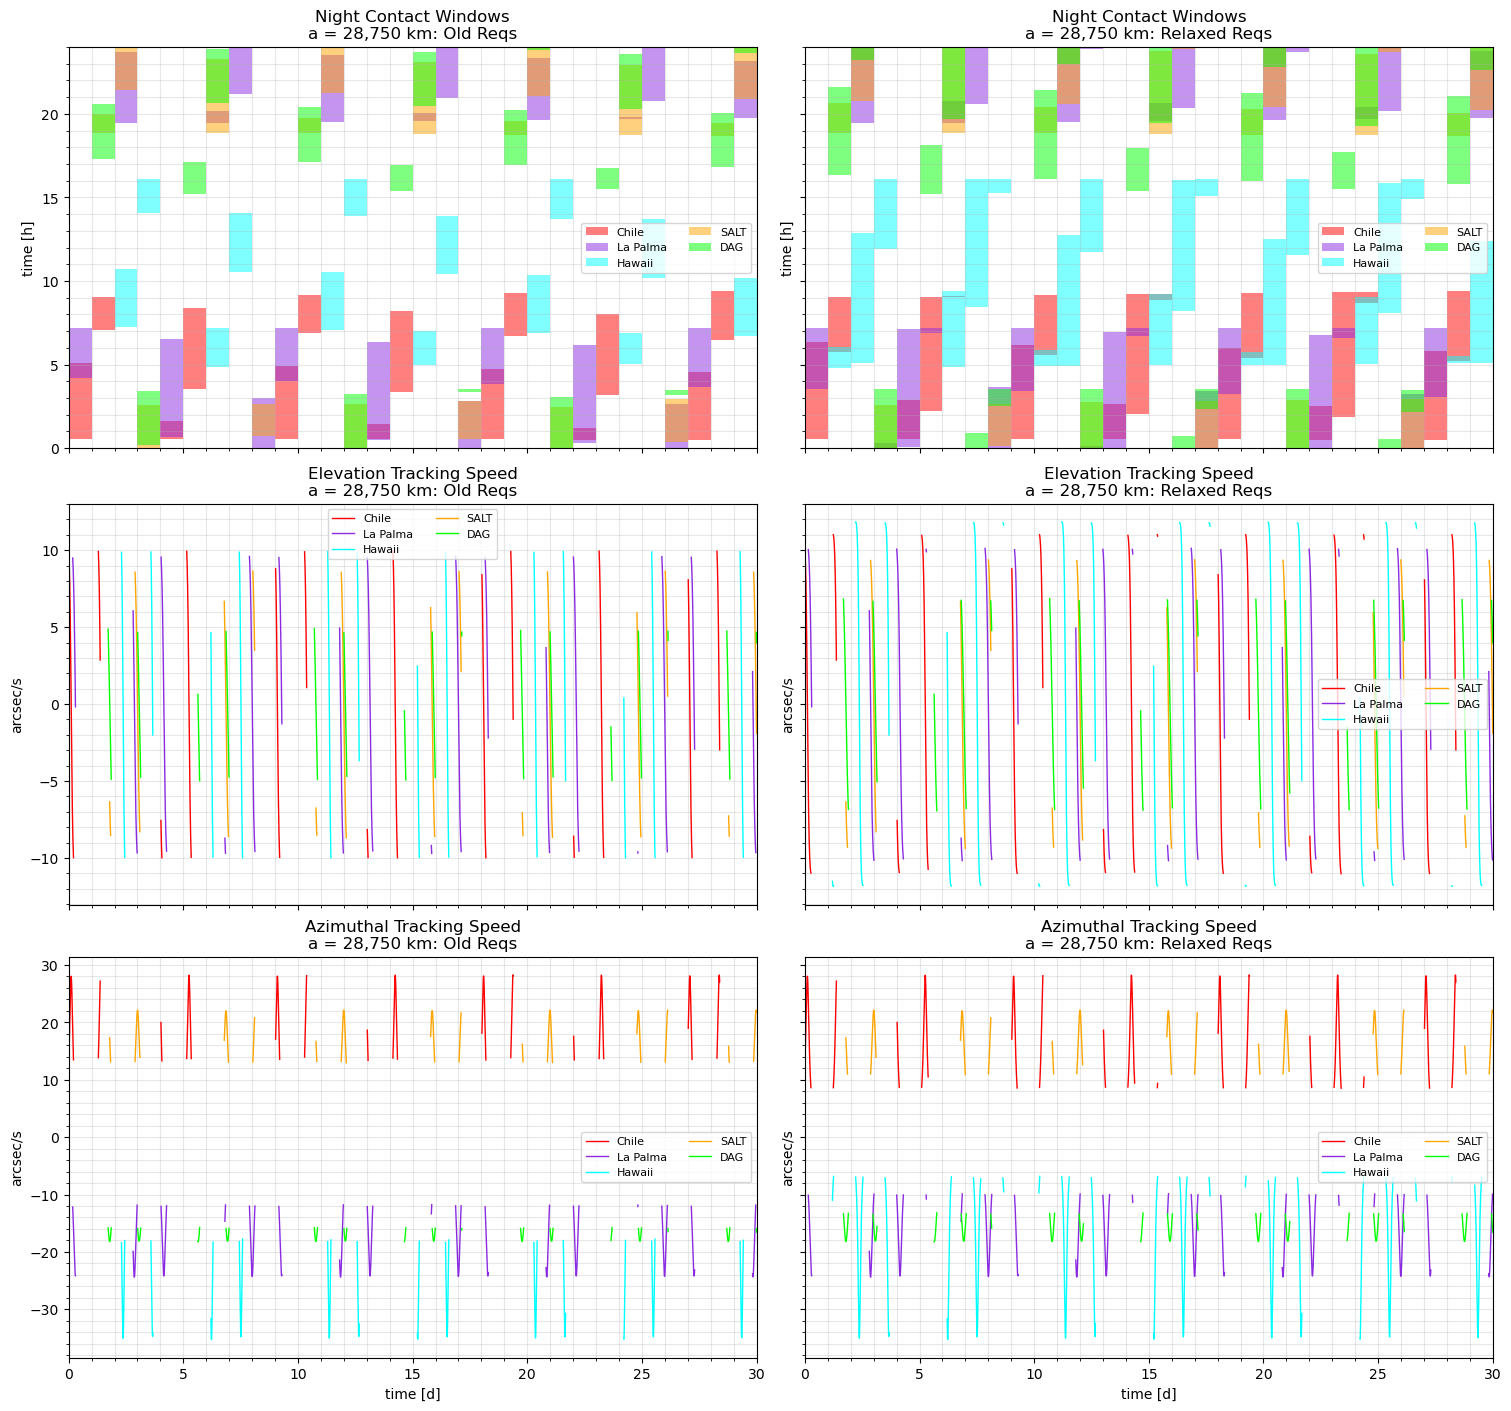

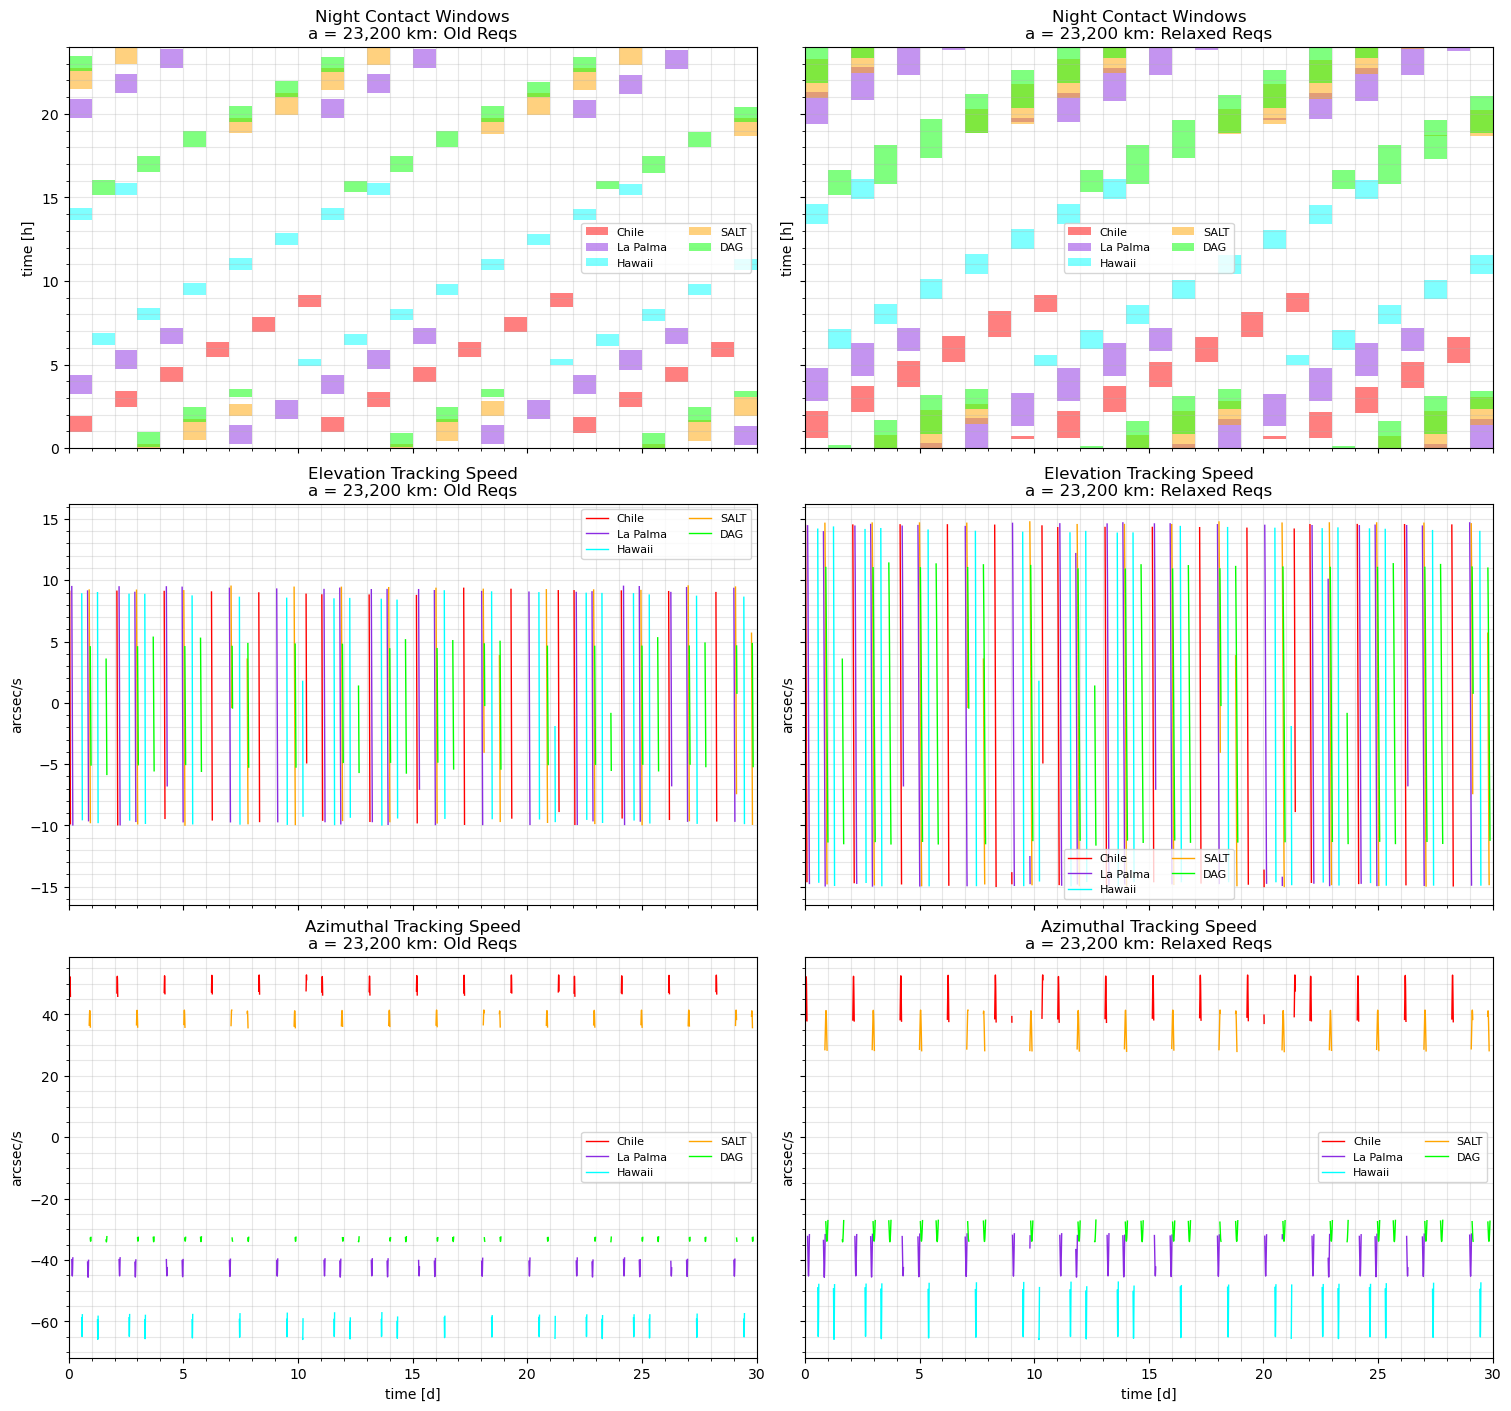

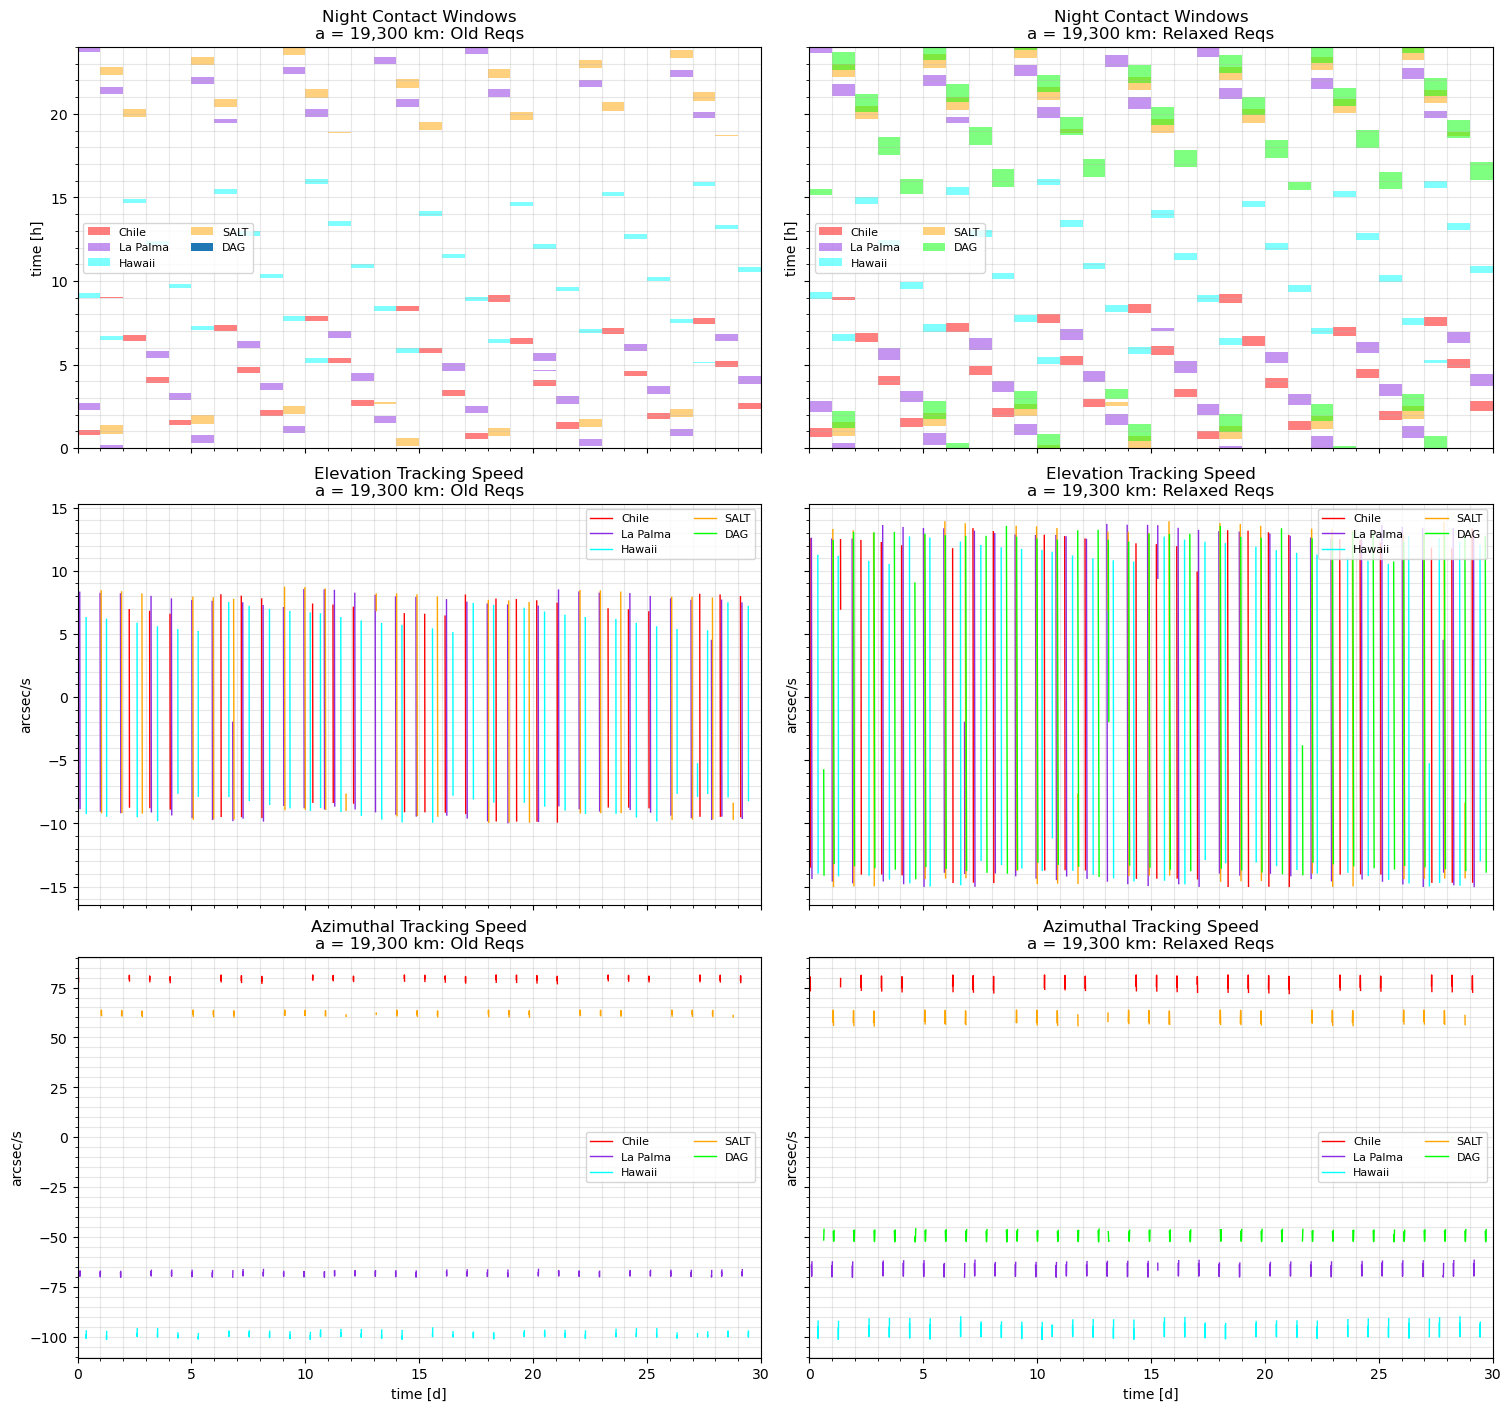

In [4]:
def plot_contact_windows(ax, folder, title):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    day = np.floor(time) + 0.5
    hour = (time - np.floor(time)) * 24
    dt_hours = np.median(np.diff(time)) * 24

    for i, station in enumerate(stations):
        visible = data[:, i + 1] == 1
        ax.bar(day[visible], np.full(visible.sum(), dt_hours),
               width=1, bottom=hour[visible],
               color=colors[i], alpha=0.5, label=station)

    ax.set_title(title)
    ax.set_ylabel("time [h]")
    ax.set_xlim(0, DAYS)
    ax.set_ylim(0, 24)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


def plot_speed(ax, folder, filename, title, requirement=None):
    data = read_result(folder, filename)
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    values = data[:, 1:].copy()

    # Ignore zeros outside contact windows
    values[values == 0] = np.nan

    for i, station in enumerate(stations):
        ax.plot(time, values[:, i], color=colors[i],
                linewidth=1, label=station)

    # Optional horizontal line showing the telescope requirement
    if SHOW_REQUIREMENTS and requirement is not None:
        ax.axhline(requirement, color="black", linestyle="--",
                   linewidth=1.2,
                   label=f"Requirement: {requirement:g} arcsec/s")

    ax.set_title(title)
    ax.set_ylabel("arcsec/s")
    ax.set_xlim(0, DAYS)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


# One figure per semi-major axis; old and relaxed requirements are side by side
for case in cases:
    a = case["a"]

    fig, axes = plt.subplots(
        3, 2,
        figsize=(15, 14),
        sharex=True,
        sharey="row",
        constrained_layout=True)

    for col, (req_name, folder) in enumerate(case["folders"].items()):
        subtitle = f"a = {a:,} km: {req_name}"

        # Elevation limit is 10 arcsec/s for old requirements and 15 for relaxed
        elevation_limit = 10 if req_name == "Old Reqs" else 15

        plot_contact_windows(
            axes[0, col], folder,
            f"Night Contact Windows\n{subtitle}")

        plot_speed(
            axes[1, col], folder,
            "Elevation Speed.txt",
            f"Elevation Tracking Speed\n{subtitle}",
            requirement=elevation_limit)

        plot_speed(
            axes[2, col], folder,
            "Azimuthal Speed.txt",
            f"Azimuthal Tracking Speed\n{subtitle}",
            requirement=600)

        axes[2, col].set_xlabel("time [d]")

    # Change SAVE_FIGURES to True to save each figure
    if SAVE_FIGURES:
        output = BASE / "comparison_plots"
        output.mkdir(exist_ok=True)

        fig.savefig(
            output / f"comparison_a{a}.png",
            dpi=300,
            bbox_inches="tight")

    plt.show()

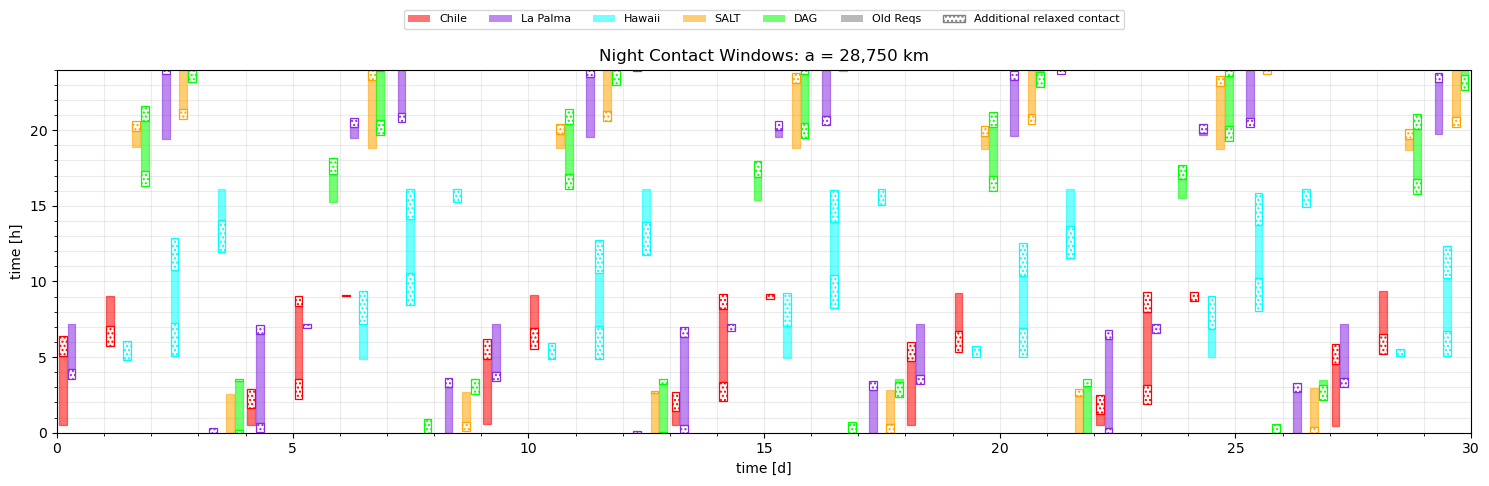

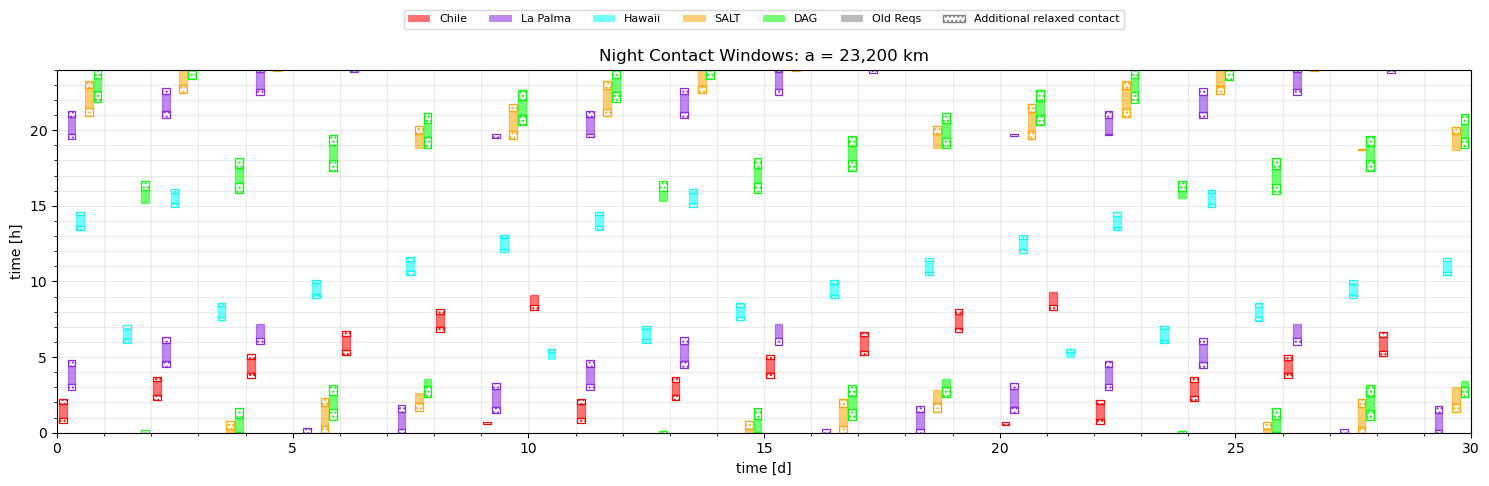

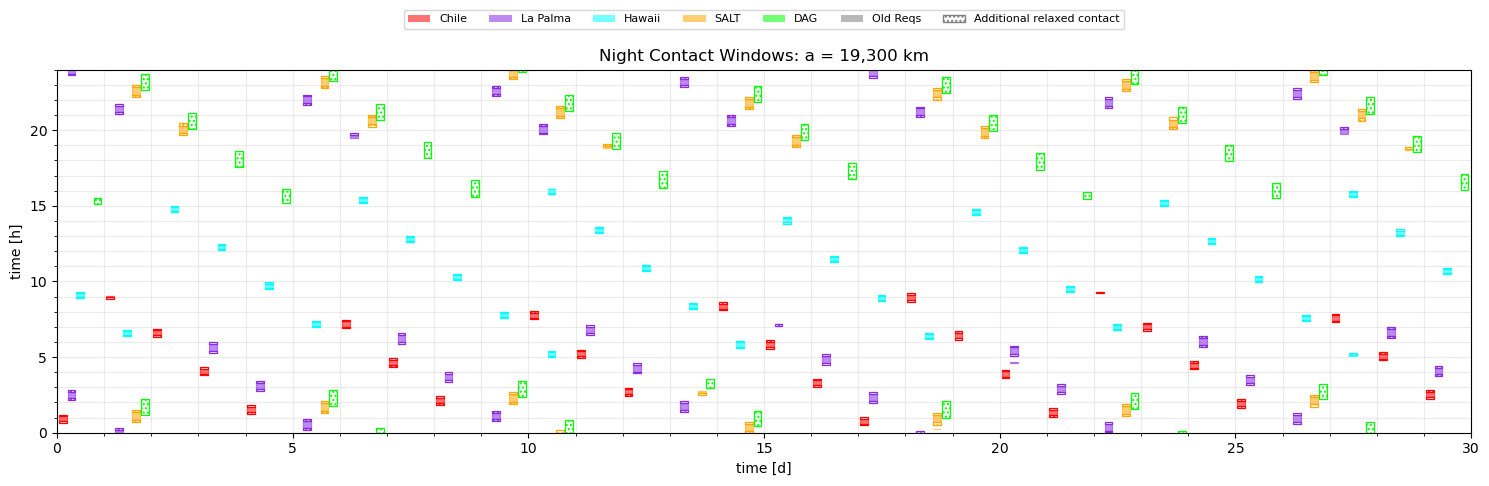

In [5]:
from matplotlib.patches import Patch, Rectangle

SELECTED_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
RELAXED_HATCH = "...."


def get_contact_segments(time, visible):
    """Return contact segments as (day, start hour, duration hours)."""
    dt = np.median(np.diff(time))
    padded = np.r_[False, visible, False]

    starts = np.where(np.diff(padded.astype(int)) == 1)[0]
    ends = np.where(np.diff(padded.astype(int)) == -1)[0]

    segments = []

    for start, end in zip(starts, ends):
        t_start = time[start]
        t_end = min(time[end - 1] + dt, DAYS)

        # Split contacts crossing midnight
        while t_start < t_end:
            day = int(np.floor(t_start))
            segment_end = min(t_end, day + 1)

            segments.append((
                day,
                (t_start - day) * 24,
                (segment_end - t_start) * 24))

            t_start = segment_end

    return segments


def draw_segments(ax, segments, x_position, width, color,
                  solid=True, hatch=None):
    for day, start_hour, duration in segments:
        ax.add_patch(Rectangle(
            (day + x_position, start_hour),
            width,
            duration,
            facecolor=color if solid else "none",
            edgecolor=color,
            alpha=0.55 if solid else 1,
            hatch=hatch,
            linewidth=0.9))


# Telescope and requirement legend
legend_handles = [
    Patch(facecolor=colors[stations.index(station)],
          alpha=0.55, label=station)
    for station in SELECTED_TELESCOPES]

legend_handles += [
    Patch(facecolor="grey", alpha=0.55, label="Old Reqs"),
    Patch(facecolor="none", edgecolor="grey",
          hatch=RELAXED_HATCH, label="Additional relaxed contact")]


# One separate figure for each semi-major axis
for case in cases:
    old_data = read_result(
        case["folders"]["Old Reqs"], "InContact.txt")
    relaxed_data = read_result(
        case["folders"]["Relaxed Reqs"], "InContact.txt")

    old_data = old_data[
        (old_data[:, 0] >= 0) & (old_data[:, 0] < DAYS)]
    relaxed_data = relaxed_data[
        (relaxed_data[:, 0] >= 0) & (relaxed_data[:, 0] < DAYS)]

    if old_data.shape != relaxed_data.shape or not np.allclose(
        old_data[:, 0], relaxed_data[:, 0]):
        raise ValueError(
            f"Time grids do not match for a = {case['a']:,} km.")

    time = old_data[:, 0]

    fig, ax = plt.subplots(figsize=(15, 5))

    # Divide each day into one narrow lane per telescope
    lane_width = 0.92 / len(SELECTED_TELESCOPES)
    rectangle_width = 0.9 * lane_width

    for j, station in enumerate(SELECTED_TELESCOPES):
        i = stations.index(station)
        color = colors[i]

        old_visible = old_data[:, i + 1] == 1
        relaxed_visible = relaxed_data[:, i + 1] == 1

        # Show only the visibility gained by relaxing the requirements
        relaxed_only = relaxed_visible & ~old_visible

        old_segments = get_contact_segments(time, old_visible)
        relaxed_segments = get_contact_segments(time, relaxed_only)

        x_position = 0.04 + j * lane_width

        draw_segments(
            ax, old_segments, x_position,
            rectangle_width, color, solid=True)

        draw_segments(
            ax, relaxed_segments, x_position,
            rectangle_width, color,
            solid=False, hatch=RELAXED_HATCH)

    ax.set_title(f"Night Contact Windows: a = {case['a']:,} km")
    ax.set_xlabel("time [d]")
    ax.set_ylabel("time [h]")
    ax.set_xlim(0, DAYS)
    ax.set_ylim(0, 24)
    ax.set_xticks(np.arange(0, DAYS + 1, 5))
    ax.set_yticks(np.arange(0, 25, 5))
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.25)
    ax.set_axisbelow(True)

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        ncol=len(legend_handles),
        fontsize=8)

    plt.tight_layout()

    if SAVE_FIGURES:
        output = BASE / "comparison_plots"
        output.mkdir(exist_ok=True)

        fig.savefig(
            output / f"contact_windows_comparison_a{case['a']}.png",
            dpi=300,
            bbox_inches="tight")

    plt.show()

In [6]:
MU_EARTH = 398600.4418  # Earth's gravitational parameter [km^3/s^2]


def contact_statistics(folder):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]            # Elapsed simulation time [days]
    in_contact = data[:, 1:] == 1  # One Boolean column per telescope

    # A new contact window begins whenever InContact changes from 0 to 1.
    # The first row is compared with an initial value of 0, so a contact already active at the start of the selected period is counted.
    previous = np.vstack((
        np.zeros((1, in_contact.shape[1]), dtype=bool),
        in_contact[:-1]))
    contact_starts = in_contact & ~previous

    duration_days = time[-1] - time[0]

    # Count the contact-window starts for each telescope, then divide by the simulation duration to obtain contacts/day for each telescope.
    contacts_per_day_per_telescope = contact_starts.sum(axis=0) / duration_days

    # The table reports the mean contacts/day across the five telescopes.
    mean_contacts_per_day = contacts_per_day_per_telescope.mean()

    # Convert the mean contact rate into an equivalent average interval: interval [h] = 24 [h/day] / contacts [contacts/day].
    # This is derived from the mean rate, not from the individual time gaps.
    mean_interval_hours = (
        24 / mean_contacts_per_day
        if mean_contacts_per_day > 0 else np.nan)

    return mean_contacts_per_day, mean_interval_hours


def tracking_speed_range(folder):
    data = read_result(folder, "Tracking Speed.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    maxima = []

    # Find the largest non-zero absolute tracking speed for each telescope.
    for values in data[:, 1:].T:
        values = np.abs(values[np.isfinite(values) & (values != 0)])

        if values.size:
            maxima.append(values.max())

    # Return the range of telescope-specific maximum tracking speeds.
    return min(maxima), max(maxima)


def fmt(value, decimals=2):
    # Remove unnecessary trailing zeros from displayed values.
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


columns = {}

for case in cases:
    a = case["a"]

    # Circular-orbit period calculated using Kepler's third law.
    period_hours = 2 * np.pi * np.sqrt(a**3 / MU_EARTH) / 3600

    for req_name, folder in case["folders"].items():
        contacts_per_day, interval_hours = contact_statistics(folder)
        speed_min, speed_max = tracking_speed_range(folder)

        columns[(case["name"], req_name)] = [
            f"{a:,} km",
            f"{period_hours:.3f} h",
            "0°",
            f"{contacts_per_day:.3f}",
            f"{interval_hours:.2f} h",
            f"{fmt(speed_min)} – {fmt(speed_max)} arcsec/s"]


# Each case has two columns: old requirements and relaxed requirements.
summary = pd.DataFrame(columns, index=[
    "Semi-major axis",
    "Orbit period",
    "Orbit inclination",
    "Mean night contacts/day per telescope",
    "Equivalent mean interval between night contacts",
    "Max. tracking speed for different latitudes"])

summary.columns = pd.MultiIndex.from_tuples(summary.columns)
summary.index.name = "Orbit"

table_styles = [
    {"selector": "th", "props": [
        ("text-align", "center"),
        ("font-weight", "bold"),
        ("border", "1px solid black")]},
    {"selector": "td", "props": [
        ("text-align", "center"),
        ("border", "1px solid black")]}]

display(summary.style.set_table_styles(table_styles))

##### Mean contacts/day per telescope: how many valid night contacts does one telescope obtain per day on average. It is not the total number of contacts produced by the full network.
##### The inverse of a rate in contacts/day gives days/contact. Multiplying by 24 gives the equivalent interval in hours. For example, 0.473 contacts/day gives 24 / 0.473 = 50.70 h. This is a rate-derived equivalent interval. It is not the arithmetic mean of the actual time gaps between consecutive contact starts. If contact spacing is irregular, those two quantities can differ.
##### If the five station maxima are 13.87, 14.02, 14.31, 14.55 and 14.71 arcsec/s, the table reports 13.87-14.71 arcsec/s. This is the range of station-specific maxima, not the minimum and maximum of every tracking-speed sample in the simulation.

##### The Table in Chapter 4.2 of Orbit Analysis v1.2 original Contacts/day and Interval between contacts values were the theoretical equatorial synodic recurrence values, which depend only on the orbit and would therefore be identical for the old and relaxed requirements. The code above instead measures completed night-contact windows from each simulation, making it more useful for this comparison.

##### The calculation of the theoretical synodic period values is done below to ensure results match with Orbit Analysis v1.2 document.

In [7]:
MU_EARTH = 398600.4418       # Earth's gravitational parameter [km^3/s^2]
EARTH_ROTATION_HOURS = 23.9344696  # Sidereal rotation period [h]


def theoretical_contact_statistics(period_hours):
    # For a prograde equatorial orbit, contact geometry repeats according to the relative angular motion of the spacecraft and the rotating Earth.
    synodic_period_hours = 1 / abs(
        1 / period_hours - 1 / EARTH_ROTATION_HOURS)

    # The original table defines contacts/day as the number of theoretical recurrence intervals contained in one 24-hour day.
    contacts_per_day = 24 / synodic_period_hours

    # This interval is theoretical and depends only on the orbital period.
    # It does not account for nighttime, minimum elevation, tracking limits, telescope longitude, or whether an actual contact is completed.
    return contacts_per_day, synodic_period_hours


def tracking_speed_range(folder):
    data = read_result(folder, "Tracking Speed.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    maxima = []

    # Maximum non-zero absolute tracking speed reached by each telescope.
    for values in data[:, 1:].T:
        values = np.abs(values[np.isfinite(values) & (values != 0)])

        if values.size:
            maxima.append(values.max())

    # Range between the five telescope-specific maximum values.
    return min(maxima), max(maxima)


def fmt(value, decimals=2):
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


columns = {}

for case in cases:
    a = case["a"]

    # Circular-orbit period from Kepler's third law.
    period_hours = 2 * np.pi * np.sqrt(a**3 / MU_EARTH) / 3600

    # These values depend only on the orbit, so they are identical for the old and relaxed telescope requirements.
    contacts_per_day, interval_hours = theoretical_contact_statistics(
        period_hours)

    for req_name, folder in case["folders"].items():
        speed_min, speed_max = tracking_speed_range(folder)

        columns[(case["name"], req_name)] = [
            f"{a:,} km",
            f"{period_hours:.3f} h",
            "0°",
            f"{contacts_per_day:.3f}",
            f"{interval_hours:.2f} h",
            f"{fmt(speed_min)} – {fmt(speed_max)} arcsec/s"]


summary = pd.DataFrame(columns, index=[
    "Semi-major axis",
    "Orbit period",
    "Orbit inclination",
    "Theoretical contacts/day",
    "Theoretical interval between contacts",
    "Max. tracking speed for different latitudes"])

summary.columns = pd.MultiIndex.from_tuples(summary.columns)
summary.index.name = "Orbit"

table_styles = [
    {"selector": "th", "props": [
        ("text-align", "center"),
        ("font-weight", "bold"),
        ("border", "1px solid black")]},
    {"selector": "td", "props": [
        ("text-align", "center"),
        ("border", "1px solid black")]}]

display(summary.style.set_table_styles(table_styles))

### Summary: The synodic method computes an idealised recurrence from the relative angular motion of a prograde equatorial spacecraft and the rotating Earth. It reproduces the original table because it does not apply telescope constraints. The simulation-statistics method detects 0-to-1 transitions in each telescope's InContact history, divides the event count by the analysed duration, averages the rates across stations, and converts the mean rate into an equivalent interval. This second method is the more accurate representation of usable telescope visibility under the old and relaxed requirements.

In [8]:
# Telescopes to include in the statistics
SELECTED_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]


def contact_intervals(time, visible):
    """Return the start and end time of every continuous contact window."""
    dt = np.median(np.diff(time))
    end_of_data = time[-1] + dt

    # Detect transitions into and out of contact
    changes = np.diff(visible.astype(int))
    starts = list(time[1:][changes == 1])
    ends = list(time[1:][changes == -1])

    # Include contacts already active at the start or end of the data
    if visible[0]:
        starts.insert(0, time[0])
    if visible[-1]:
        ends.append(end_of_data)

    return np.array(starts), np.array(ends), end_of_data


def visibility_statistics(time, visible):
    starts, ends, end_of_data = contact_intervals(time, visible)

    # Duration of each continuous contact window [h]
    durations = (ends - starts) * 24

    if durations.size:
        median_duration = np.median(durations)
        maximum_duration = np.max(durations)
        total_contact = np.sum(durations)
    else:
        median_duration = np.nan
        maximum_duration = np.nan
        total_contact = 0.0

    # Gaps include the beginning and end of the selected simulation period
    if starts.size:
        gaps = [starts[0] - time[0]]
        gaps.extend(starts[1:] - ends[:-1])
        gaps.append(end_of_data - ends[-1])
        maximum_gap = np.max(gaps) * 24
    else:
        maximum_gap = (end_of_data - time[0]) * 24

    return {
        "total_contact_h": total_contact,
        "median_duration_h": median_duration,
        "maximum_duration_h": maximum_duration,
        "maximum_gap_h": maximum_gap
    }


rows = []

for case in cases:
    old_folder = case["folders"]["Old Reqs"]
    relaxed_folder = case["folders"]["Relaxed Reqs"]

    old_data = read_result(old_folder, "InContact.txt")
    relaxed_data = read_result(relaxed_folder, "InContact.txt")

    # Restrict both simulations to the selected analysis period
    old_data = old_data[(old_data[:, 0] >= 0) & (old_data[:, 0] <= DAYS)]
    relaxed_data = relaxed_data[
        (relaxed_data[:, 0] >= 0) & (relaxed_data[:, 0] <= DAYS)]

    # Statistics require matching output times
    if old_data.shape != relaxed_data.shape or not np.allclose(
        old_data[:, 0], relaxed_data[:, 0]):
        raise ValueError(
            f"Old and relaxed time grids do not match for a = {case['a']:,} km.")

    time = old_data[:, 0]

    for station in SELECTED_TELESCOPES:
        i = stations.index(station)

        old_visible = old_data[:, i + 1] == 1
        relaxed_visible = relaxed_data[:, i + 1] == 1

        old_stats = visibility_statistics(time, old_visible)
        relaxed_stats = visibility_statistics(time, relaxed_visible)

        # Integrate only timesteps newly accepted by the relaxed requirements
        dt_hours = np.median(np.diff(time)) * 24
        relaxed_only = relaxed_visible & ~old_visible
        additional_hours = relaxed_only.sum() * dt_hours

        increase_percent = (
            100 * additional_hours / old_stats["total_contact_h"]
            if old_stats["total_contact_h"] > 0 else np.nan)

        rows.append({
            "Semi-major axis [km]": case["a"],
            "Telescope": station,
            "Old total contact [h]": old_stats["total_contact_h"],
            "Relaxed total contact [h]": relaxed_stats["total_contact_h"],
            "Additional contact [h]": additional_hours,
            "Contact increase [%]": increase_percent,
            "Old median duration [h]": old_stats["median_duration_h"],
            "Relaxed median duration [h]": relaxed_stats["median_duration_h"],
            "Old maximum duration [h]": old_stats["maximum_duration_h"],
            "Relaxed maximum duration [h]": relaxed_stats["maximum_duration_h"],
            "Old maximum gap [h]": old_stats["maximum_gap_h"],
            "Relaxed maximum gap [h]": relaxed_stats["maximum_gap_h"]})


contact_stats = pd.DataFrame(rows).round(2)
display(contact_stats)

,Semi-major axis [km],Telescope,Old total contact [h],Relaxed total contact [h],Additional contact [h],Contact increase [%],Old median duration [h],Relaxed median duration [h],Old maximum duration [h],Relaxed maximum duration [h],Old maximum gap [h],Relaxed maximum gap [h]
0,28750,Chile,44.07,66.17,22.10,50.15,3.48,3.90,4.83,7.47,88.47,63.50
1,28750,La Palma,64.90,80.17,15.27,23.52,3.70,4.07,5.87,7.07,61.53,60.60
2,28750,Hawaii,37.43,86.37,48.93,130.72,3.47,4.33,3.53,7.83,89.00,60.90
3,28750,SALT,42.33,52.13,9.80,23.15,2.85,3.50,5.37,6.50,88.30,88.27
4,28750,DAG,38.13,63.13,25.00,65.56,3.23,4.57,3.33,5.30,61.53,60.57
5,23200,Chile,14.27,24.30,10.03,70.33,0.90,1.57,0.93,1.57,48.60,47.97
6,23200,La Palma,25.53,43.33,17.80,69.71,1.13,1.97,1.17,2.00,48.37,47.53
7,23200,Hawaii,14.70,24.50,9.80,66.67,0.70,1.17,0.70,1.17,48.80,48.33
8,23200,SALT,20.00,34.47,14.47,72.33,1.30,2.33,1.33,2.37,48.20,47.17
9,23200,DAG,22.00,53.47,31.47,143.03,0.90,2.30,1.00,2.33,48.60,47.23


In [9]:
summary_stats = (
    contact_stats
    .groupby("Semi-major axis [km]", as_index=False)
    .mean(numeric_only=True)
    .round(2))

display(summary_stats)

,Semi-major axis [km],Old total contact [h],Relaxed total contact [h],Additional contact [h],Contact increase [%],Old median duration [h],Relaxed median duration [h],Old maximum duration [h],Relaxed maximum duration [h],Old maximum gap [h],Relaxed maximum gap [h]
0,19300,8.31,20.35,12.06,57.59,0.38,0.69,0.39,0.72,178.03,40.09
1,23200,19.30,36.01,16.71,84.41,0.99,1.87,1.03,1.89,48.51,47.65
2,28750,45.37,69.59,24.22,58.62,3.35,4.07,4.59,6.83,77.77,66.77


#### Below will analyse with the following requirements:
##### For each telescope independently, each complete local night must contain at least one continuous valid-contact interval lasting 30 minutes or more. No more than two consecutive nights may lack such a contact. In a longer missed-night streak, only the third and subsequent nights are counted as “invalid nights".

Invalid nights counts only nights that exceed the permitted two-night missed-contact sequence. For example:

- A two-night missed streak produces 0 invalid nights.
- A three-night missed streak produces 1 invalid night.
- A five-night missed streak produces 3 invalid nights.

In [10]:
# Contact requirement settings
MIN_VALID_CONTACT_H = 0.5  # 30 minutes
MAX_CONSECUTIVE_MISSED_NIGHTS = 2
REQUIREMENT_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
EXCLUDE_PARTIAL_EDGE_NIGHTS = True # If true, a nighttime interval already underway when the simulation begins, 
                                   # or unfinished when it ends, is excluded. 
                                   # This prevents a partial night from being incorrectly classified as missed.


def infer_simulation_end(time):
    """Infer the simulation end time from the output samples."""
    if len(time) < 2:
        raise ValueError("At least two output time samples are required.")

    time_steps = np.diff(time)

    if not np.all(time_steps > 0):
        raise ValueError("Output times must be strictly increasing.")

    dt = np.median(time_steps)

    return time[-1] + dt


def get_boolean_intervals(time, state, simulation_end):
    """Return the start and end times of each continuous True interval."""
    state = np.asarray(state, dtype=bool)

    if len(time) != len(state):
        raise ValueError("Time and Boolean state arrays must have equal lengths.")

    padded = np.r_[False, state, False]
    start_indices = np.where(np.diff(padded.astype(int)) == 1)[0]
    end_indices = np.where(np.diff(padded.astype(int)) == -1)[0]

    interval_starts = time[start_indices]
    interval_ends = np.array([time[index] if index < len(time) else simulation_end
                              for index in end_indices])

    return interval_starts, interval_ends


def get_night_intervals(time, is_night, simulation_end):
    """
    Return the continuous nighttime intervals for one telescope.

    When EXCLUDE_PARTIAL_EDGE_NIGHTS is True, a night already underway
    at the start of the simulation or unfinished at the end is excluded.
    """
    night_starts, night_ends = get_boolean_intervals(
        time, is_night, simulation_end)

    keep = np.ones(len(night_starts), dtype=bool)

    if EXCLUDE_PARTIAL_EDGE_NIGHTS and len(night_starts) > 0:
        if is_night[0]:
            keep[0] = False
        if is_night[-1]:
            keep[-1] = False

    return night_starts[keep], night_ends[keep]


def get_missed_night_runs(night_has_valid_contact):
    """Return inclusive ranges of consecutive nights without valid contact."""
    runs = []
    run_start = None

    for night_index, has_contact in enumerate(night_has_valid_contact):
        if not has_contact and run_start is None:
            run_start = night_index
        elif has_contact and run_start is not None:
            runs.append((run_start, night_index - 1))
            run_start = None

    if run_start is not None:
        runs.append((run_start, len(night_has_valid_contact) - 1))

    return runs


def evaluate_telescope_requirements(time, visible, is_night, simulation_end):
    """
    Evaluate both requirements for one telescope.

    Requirement 1:
        A continuous contact within a nighttime interval must last at
        least 30 minutes.

    Requirement 2:
        At most two consecutive nights may have no valid contact.
        In longer streaks, nights from the third missed night onward
        are counted as cadence-invalid.
    """
    night_starts, night_ends = get_night_intervals(
        time, is_night, simulation_end)

    if len(night_starts) == 0:
        raise ValueError("No complete nighttime intervals were found.")

    contact_starts, contact_ends = get_boolean_intervals(
        time, visible, simulation_end)

    night_has_valid_contact = np.zeros(len(night_starts), dtype=bool)
    valid_contact_count = 0

    for night_index, (night_start, night_end) in enumerate(
        zip(night_starts, night_ends)):

        overlap_starts = np.maximum(contact_starts, night_start)
        overlap_ends = np.minimum(contact_ends, night_end)
        overlap_durations_h = np.maximum(0, overlap_ends - overlap_starts) * 24
        valid_contacts = overlap_durations_h >= MIN_VALID_CONTACT_H - 1e-9

        night_has_valid_contact[night_index] = np.any(valid_contacts)
        valid_contact_count += int(valid_contacts.sum())

    missed_runs = get_missed_night_runs(night_has_valid_contact)

    longest_missed_streak = max(
        (end - start + 1 for start, end in missed_runs), default=0)

    invalid_nights = sum(
        max(0, end - start + 1 - MAX_CONSECUTIVE_MISSED_NIGHTS)
        for start, end in missed_runs)

    violating_streaks = [
        f"Nights {start + 1}–{end + 1}"
        for start, end in missed_runs
        if end - start + 1 > MAX_CONSECUTIVE_MISSED_NIGHTS]

    return {"Analysed nights": len(night_starts),
            "Valid contacts [≥30 min]": valid_contact_count,
            "Nights with valid contact": int(night_has_valid_contact.sum()),
            "Missed nights": int((~night_has_valid_contact).sum()),
            "Invalid nights": invalid_nights,
            "Longest missed streak [nights]": longest_missed_streak,
            "Cadence requirement satisfied": "Yes" if invalid_nights == 0 else "No",
            "Violating streaks": ", ".join(violating_streaks)
            if violating_streaks else "None"}


def create_orbit_requirement_table(case):
    """Create one telescope requirement table for one orbit."""
    rows = []

    for requirement_name, folder in case["folders"].items():
        contact_data = read_result(folder, "InContact.txt")
        night_data = read_result(folder, "IsNight.txt")

        contact_time = contact_data[:, 0]
        night_time = night_data[:, 0]

        if len(contact_time) != len(night_time):
            raise ValueError(
                f"InContact.txt and IsNight.txt have different lengths in {folder}.")

        if not np.allclose(contact_time, night_time, rtol=0, atol=1e-10):
            raise ValueError(
                f"InContact.txt and IsNight.txt use different time samples in {folder}.")

        simulation_end = infer_simulation_end(contact_time)

        for telescope in REQUIREMENT_TELESCOPES:
            column = stations.index(telescope) + 1
            visible = contact_data[:, column] >= 0.5
            is_night = night_data[:, column] >= 0.5

            result = evaluate_telescope_requirements(
                contact_time, visible, is_night, simulation_end)

            rows.append({"Requirements": requirement_name,
                         "Telescope": telescope,
                         **result})

    return pd.DataFrame(rows)


# Display one table for each orbit
requirement_tables = {}

for case in cases:
    orbit_name = case["name"]
    orbit_table = create_orbit_requirement_table(case)
    requirement_tables[orbit_name] = orbit_table

    print(f"\n{orbit_name} (a = {case['a']:.0f} km)")
    display(orbit_table.style.hide(axis="index"))


28750 km (a = 28750 km)


Requirements,Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied,Violating streaks
Old Reqs,Chile,30,14,14,16,3,3,No,"Nights 7–9, Nights 16–18, Nights 25–27"
Old Reqs,La Palma,29,13,13,16,2,3,No,"Nights 14–16, Nights 23–25"
Old Reqs,Hawaii,30,13,13,17,3,3,No,"Nights 9–11, Nights 18–20, Nights 27–29"
Old Reqs,SALT,29,13,13,16,3,3,No,"Nights 4–6, Nights 13–15, Nights 22–24"
Old Reqs,DAG,29,13,13,16,3,3,No,"Nights 8–10, Nights 17–19, Nights 26–28"
Relaxed Reqs,Chile,30,15,15,15,2,3,No,"Nights 7–9, Nights 16–18"
Relaxed Reqs,La Palma,29,16,16,13,0,2,Yes,None
Relaxed Reqs,Hawaii,30,19,19,11,0,2,Yes,None
Relaxed Reqs,SALT,29,13,13,16,3,3,No,"Nights 4–6, Nights 13–15, Nights 22–24"
Relaxed Reqs,DAG,29,16,16,13,0,2,Yes,None



23200 km (a = 23200 km)


Requirements,Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied,Violating streaks
Old Reqs,Chile,30,16,16,14,0,1,Yes,None
Old Reqs,La Palma,29,22,22,7,0,1,Yes,None
Old Reqs,Hawaii,30,20,20,10,0,1,Yes,None
Old Reqs,SALT,29,16,16,13,0,1,Yes,None
Old Reqs,DAG,29,21,21,8,0,1,Yes,None
Relaxed Reqs,Chile,30,16,16,14,0,1,Yes,None
Relaxed Reqs,La Palma,29,22,22,7,0,1,Yes,None
Relaxed Reqs,Hawaii,30,22,22,8,0,1,Yes,None
Relaxed Reqs,SALT,29,16,16,13,0,1,Yes,None
Relaxed Reqs,DAG,29,25,25,4,0,1,Yes,None



19300 km (a = 19300 km)


Requirements,Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied,Violating streaks
Old Reqs,Chile,30,0,0,30,28,30,No,Nights 1–30
Old Reqs,La Palma,29,0,0,29,27,29,No,Nights 1–29
Old Reqs,Hawaii,30,0,0,30,28,30,No,Nights 1–30
Old Reqs,SALT,29,3,3,26,18,13,No,"Nights 1–8, Nights 10–22, Nights 24–26"
Old Reqs,DAG,29,0,0,29,27,29,No,Nights 1–29
Relaxed Reqs,Chile,30,24,24,6,0,1,Yes,None
Relaxed Reqs,La Palma,29,30,29,0,0,0,Yes,None
Relaxed Reqs,Hawaii,30,0,0,30,28,30,No,Nights 1–30
Relaxed Reqs,SALT,29,21,21,8,0,2,Yes,None
Relaxed Reqs,DAG,29,33,29,0,0,0,Yes,None


In [11]:
# Summary table: invalid nights per telescope for each orbit and requirement level
summary_rows = []

for orbit_name, orbit_table in requirement_tables.items():
    for requirement_name in orbit_table["Requirements"].unique():
        requirement_data = orbit_table[
            orbit_table["Requirements"] == requirement_name]

        row = {"Orbit": orbit_name,
               "Requirements": requirement_name}

        for telescope in REQUIREMENT_TELESCOPES:
            telescope_data = requirement_data[
                requirement_data["Telescope"] == telescope]

            row[telescope] = int(telescope_data["Invalid nights"].sum())

        row["Total invalid nights"] = sum(
            row[telescope] for telescope in REQUIREMENT_TELESCOPES)

        summary_rows.append(row)

invalid_nights_summary = pd.DataFrame(summary_rows)

display(invalid_nights_summary.style.hide(axis="index"))

Orbit,Requirements,Chile,La Palma,Hawaii,SALT,DAG,Total invalid nights
28750 km,Old Reqs,3,2,3,3,3,14
28750 km,Relaxed Reqs,2,0,0,3,0,5
23200 km,Old Reqs,0,0,0,0,0,0
23200 km,Relaxed Reqs,0,0,0,0,0,0
19300 km,Old Reqs,28,27,28,18,27,128
19300 km,Relaxed Reqs,0,0,28,0,0,28


## Sensitivity Analysis:
##### (Just on sma = 23,200 km, i = 0°)

In [12]:
# Four combinations for the a = 23,200 km, i = 0° sensitivity analysis
SENSITIVITY_CASES = [
    {"Case": "Old Reqs",
     "Coverage angle [deg]": 36,
     "Elevation speed limit [arcsec/s]": 10,
     "Folder": "Results_a23200_oldParams"},

    {"Case": "Coverage relaxed only",
     "Coverage angle [deg]": 30,
     "Elevation speed limit [arcsec/s]": 10,
     "Folder": "Results_a23200_coverage30_elevspeed10"},

    {"Case": "Elevation tracking speed relaxed only",
     "Coverage angle [deg]": 36,
     "Elevation speed limit [arcsec/s]": 15,
     "Folder": "Results_a23200_coverage36_elevspeed15"},

    {"Case": "Fully relaxed",
     "Coverage angle [deg]": 30,
     "Elevation speed limit [arcsec/s]": 15,
     "Folder": "Results_a23200_newParams"}]

case_order = [case["Case"] for case in SENSITIVITY_CASES]

In [13]:
# Calculate contact and cadence results for every case and telescope
sensitivity_rows = []
reference_time = None

for case in SENSITIVITY_CASES:
    contact_data = read_result(case["Folder"], "InContact.txt")
    night_data = read_result(case["Folder"], "IsNight.txt")

    contact_mask = (contact_data[:, 0] >= 0) & (contact_data[:, 0] < DAYS)
    night_mask = (night_data[:, 0] >= 0) & (night_data[:, 0] < DAYS)
    contact_data = contact_data[contact_mask]
    night_data = night_data[night_mask]

    if contact_data.shape != night_data.shape or not np.allclose(
        contact_data[:, 0], night_data[:, 0]):
        raise ValueError(
            f"InContact.txt and IsNight.txt do not match in {case['Folder']}.")

    time = contact_data[:, 0]

    if reference_time is None:
        reference_time = time
    elif len(time) != len(reference_time) or not np.allclose(
        time, reference_time):
        raise ValueError(
            f"Time grid does not match the other cases in {case['Folder']}.")

    simulation_end = infer_simulation_end(time)

    for telescope in REQUIREMENT_TELESCOPES:
        column = stations.index(telescope) + 1
        visible = contact_data[:, column] >= 0.5
        is_night = night_data[:, column] >= 0.5

        contact_stats_case = visibility_statistics(time, visible)
        requirement_stats = evaluate_telescope_requirements(
            time, visible, is_night, simulation_end)

        sensitivity_rows.append({
            "Case": case["Case"],
            "Coverage angle [deg]": case["Coverage angle [deg]"],
            "Elevation speed limit [arcsec/s]":
                case["Elevation speed limit [arcsec/s]"],
            "Telescope": telescope,
            "Total contact [h]":
                contact_stats_case["total_contact_h"],
            "Median contact duration [h]":
                contact_stats_case["median_duration_h"],
            "Maximum gap [h]":
                contact_stats_case["maximum_gap_h"],
            **requirement_stats})

sensitivity_results = pd.DataFrame(sensitivity_rows).round(2)

display(sensitivity_results.style.hide(axis="index").format(precision=2))

Case,Coverage angle [deg],Elevation speed limit [arcsec/s],Telescope,Total contact [h],Median contact duration [h],Maximum gap [h],Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied,Violating streaks
Old Reqs,36,10,Chile,14.27,0.90,48.60,30,16,16,14,0,1,Yes,None
Old Reqs,36,10,La Palma,25.53,1.13,48.37,29,22,22,7,0,1,Yes,None
Old Reqs,36,10,Hawaii,14.70,0.70,48.80,30,20,20,10,0,1,Yes,None
Old Reqs,36,10,SALT,20.00,1.30,48.20,29,16,16,13,0,1,Yes,None
Old Reqs,36,10,DAG,22.00,0.90,48.60,29,21,21,8,0,1,Yes,None
Coverage relaxed only,30,10,Chile,14.27,0.90,48.60,30,16,16,14,0,1,Yes,None
Coverage relaxed only,30,10,La Palma,25.53,1.13,48.37,29,22,22,7,0,1,Yes,None
Coverage relaxed only,30,10,Hawaii,14.70,0.70,48.80,30,20,20,10,0,1,Yes,None
Coverage relaxed only,30,10,SALT,20.00,1.30,48.20,29,16,16,13,0,1,Yes,None
Coverage relaxed only,30,10,DAG,44.33,1.90,47.60,29,25,25,4,0,1,Yes,None


In [14]:
# Network totals and the worst individual telescope streak
network_rows = []

for case in SENSITIVITY_CASES:
    case_data = sensitivity_results[
        sensitivity_results["Case"] == case["Case"]]

    network_rows.append({
        "Case": case["Case"],
        "Coverage angle [deg]": case["Coverage angle [deg]"],
        "Elevation speed limit [arcsec/s]":
            case["Elevation speed limit [arcsec/s]"],
        "Total contact [h]":
            case_data["Total contact [h]"].sum(),
        "Valid contacts [≥30 min]":
            case_data["Valid contacts [≥30 min]"].sum(),
        "Nights with valid contact":
            case_data["Nights with valid contact"].sum(),
        "Missed nights":
            case_data["Missed nights"].sum(),
        "Invalid nights":
            case_data["Invalid nights"].sum(),
        "Worst missed streak [nights]":
            case_data["Longest missed streak [nights]"].max()})

network_summary = pd.DataFrame(network_rows).round(2)

display(network_summary.style.hide(axis="index").format(precision=2))

Case,Coverage angle [deg],Elevation speed limit [arcsec/s],Total contact [h],Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Worst missed streak [nights]
Old Reqs,36,10,96.50,95,95,52,0,1
Coverage relaxed only,30,10,118.83,99,99,48,0,1
Elevation tracking speed relaxed only,36,15,148.63,97,97,50,0,1
Fully relaxed,30,15,180.07,101,101,46,0,1


In [15]:
# Changes relative to the fully old requirements
baseline = network_summary[
    network_summary["Case"] == "Old Reqs"].iloc[0]

impact_rows = []

for case_name in case_order[1:]:
    result = network_summary[
        network_summary["Case"] == case_name].iloc[0]

    impact_rows.append({
        "Case": case_name,
        "Additional contact [h]":
            result["Total contact [h]"] -
            baseline["Total contact [h]"],
        "Additional valid contacts":
            result["Valid contacts [≥30 min]"] -
            baseline["Valid contacts [≥30 min]"],
        "Additional nights with valid contact":
            result["Nights with valid contact"] -
            baseline["Nights with valid contact"],
        "Missed nights reduced":
            baseline["Missed nights"] -
            result["Missed nights"],
        "Invalid nights reduced":
            baseline["Invalid nights"] -
            result["Invalid nights"],
        "Worst missed streak reduced":
            baseline["Worst missed streak [nights]"] -
            result["Worst missed streak [nights]"]})

baseline_impacts = pd.DataFrame(impact_rows).round(2)

display(baseline_impacts.style.hide(axis="index").format(precision=2))

Case,Additional contact [h],Additional valid contacts,Additional nights with valid contact,Missed nights reduced,Invalid nights reduced,Worst missed streak reduced
Coverage relaxed only,22.33,4,4,4,0,0
Elevation tracking speed relaxed only,52.13,2,2,2,0,0
Fully relaxed,83.57,6,6,6,0,0


In [16]:
# Two-level factorial effects 
# (compare the individual and combined effects of both requirement relaxations)
factorial_data = network_summary.set_index([
    "Coverage angle [deg]",
    "Elevation speed limit [arcsec/s]"])

metric_directions = {
    "Total contact [h]": 1,
    "Valid contacts [≥30 min]": 1,
    "Nights with valid contact": 1,
    "Missed nights": -1,
    "Invalid nights": -1,
    "Worst missed streak [nights]": -1}

factorial_rows = []

for metric, direction in metric_directions.items():
    old = direction * factorial_data.loc[(36, 10), metric]
    coverage_only = direction * factorial_data.loc[(30, 10), metric]
    speed_only = direction * factorial_data.loc[(36, 15), metric]
    fully_relaxed = direction * factorial_data.loc[(30, 15), metric]

    coverage_baseline_effect = coverage_only - old
    speed_baseline_effect = speed_only - old

    coverage_mean_effect = (
        coverage_only + fully_relaxed -
        old - speed_only) / 2

    speed_mean_effect = (
        speed_only + fully_relaxed -
        old - coverage_only) / 2

    interaction = (
        fully_relaxed -
        coverage_only -
        speed_only +
        old)

    if np.isclose(
        coverage_baseline_effect,
        speed_baseline_effect):
        larger_effect = "Equal"
    elif coverage_baseline_effect > speed_baseline_effect:
        larger_effect = "Coverage relaxation"
    else:
        larger_effect = "Speed relaxation"

    
    # Can omit mean effects in reports as they present the same conclusion as baseline effects
    factorial_rows.append({
        "Metric": metric,
        "Coverage effect from old baseline":
            coverage_baseline_effect,
        "Speed effect from old baseline":
            speed_baseline_effect,
        "Coverage mean effect":
            coverage_mean_effect,
        "Speed mean effect":
            speed_mean_effect,
        "Interaction":
            interaction,
        "Larger baseline effect":
            larger_effect})

factorial_effects = pd.DataFrame(factorial_rows).round(2)

display(factorial_effects.style.hide(axis="index").format(precision=2))

Metric,Coverage effect from old baseline,Speed effect from old baseline,Coverage mean effect,Speed mean effect,Interaction,Larger baseline effect
Total contact [h],22.33,52.13,26.88,56.68,9.11,Speed relaxation
Valid contacts [≥30 min],4.00,2.00,4.00,2.00,0.00,Coverage relaxation
Nights with valid contact,4.00,2.00,4.00,2.00,0.00,Coverage relaxation
Missed nights,4.00,2.00,4.00,2.00,0.00,Coverage relaxation
Invalid nights,0.00,0.00,0.00,0.00,0.00,Equal
Worst missed streak [nights],0.00,0.00,0.00,0.00,0.00,Equal


This table compares the effect of relaxing the coverage-angle requirement from 36° to 30° and the elevation-speed limit from 10 arcsec/s to 15 arcsec/s.

* Coverage effect from old baseline: change produced by relaxing only the coverage-angle requirement, while keeping the speed limit at its old value of 10 arcsec/s.

* Speed effect from old baseline: change produced by relaxing only the elevation-speed requirement, while keeping the coverage angle at its old value of 36°.

* Coverage mean effect: average effect of relaxing the coverage-angle requirement across both speed-limit values.

$$
\text{Coverage mean effect}
=
\frac{
\left[Y(30,10)-Y(36,10)\right]
+
\left[Y(30,15)-Y(36,15)\right]
}{2}
$$

* Speed mean effect: average effect of relaxing the elevation-speed requirement across both coverage-angle values.

$$
\text{Speed mean effect}
=
\frac{
\left[Y(36,15)-Y(36,10)\right]
+
\left[Y(30,15)-Y(30,10)\right]
}{2}
$$

* Interaction: indicates whether the effect of one relaxation depends on the value of the other requirement. A value close to zero means the two relaxations act approximately independently. A positive value means the fully relaxed case performs better than expected from adding the two individual effects, while a negative value means the combined improvement is smaller than expected.

* Larger baseline effect: identifies which individual relaxation produces the larger improvement relative to the fully old requirements.

The metric directions are adjusted so that positive values always represent an improvement (positive values correspond to more contact time, more valid contacts, more nights with valid contact, fewer missed or invalid nights, and shorter missed-night streaks).


In [17]:
"""
# Invalid nights for each telescope and requirement combination
invalid_nights_by_telescope = sensitivity_results.pivot(
    index="Telescope",
    columns="Case",
    values="Invalid nights").reindex(columns=case_order)

#display(invalid_nights_by_telescope.style.format("{:.0f}"))

# Invalid nights per telescope
ax = invalid_nights_by_telescope.plot(
    kind="bar",
    figsize=(12, 5))

ax.set_title(
    "Invalid Nights Sensitivity: "
    "a = 23,200 km, i = 0°")
ax.set_xlabel("Telescope")
ax.set_ylabel("Invalid nights")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case", fontsize=8)

plt.xticks(rotation=0)
plt.tight_layout()

if SAVE_FIGURES:
    output = BASE / "sensitivity_plots"
    output.mkdir(exist_ok=True)

    plt.savefig(
        output / "invalid_nights_sensitivity_a23200.png",
        dpi=300,
        bbox_inches="tight")

plt.show()
"""

'\n# Invalid nights for each telescope and requirement combination\ninvalid_nights_by_telescope = sensitivity_results.pivot(\n    index="Telescope",\n    columns="Case",\n    values="Invalid nights").reindex(columns=case_order)\n\n#display(invalid_nights_by_telescope.style.format("{:.0f}"))\n\n# Invalid nights per telescope\nax = invalid_nights_by_telescope.plot(\n    kind="bar",\n    figsize=(12, 5))\n\nax.set_title(\n    "Invalid Nights Sensitivity: "\n    "a = 23,200 km, i = 0°")\nax.set_xlabel("Telescope")\nax.set_ylabel("Invalid nights")\nax.grid(axis="y", alpha=0.3)\nax.legend(title="Case", fontsize=8)\n\nplt.xticks(rotation=0)\nplt.tight_layout()\n\nif SAVE_FIGURES:\n    output = BASE / "sensitivity_plots"\n    output.mkdir(exist_ok=True)\n\n    plt.savefig(\n        output / "invalid_nights_sensitivity_a23200.png",\n        dpi=300,\n        bbox_inches="tight")\n\nplt.show()\n'

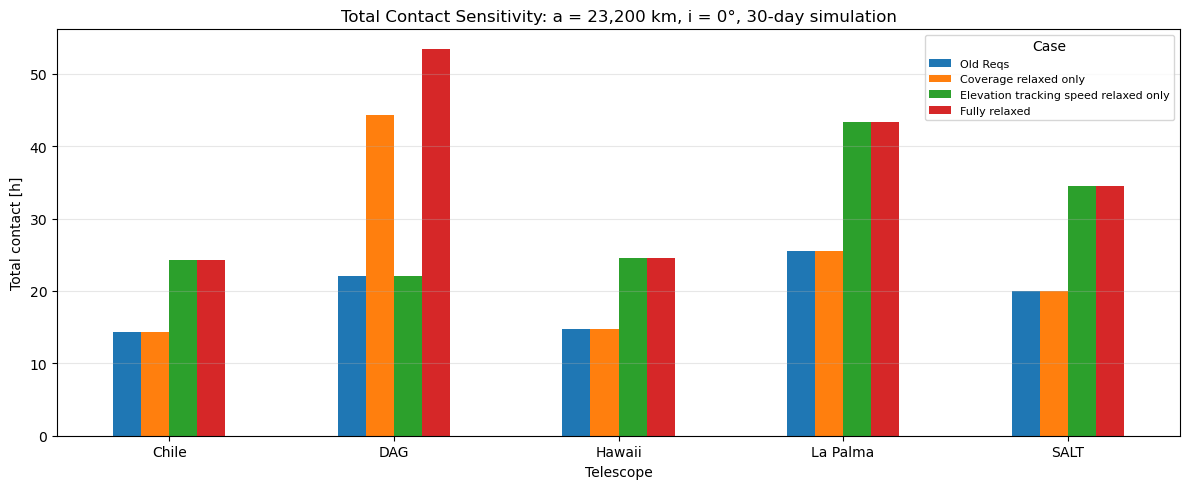

In [20]:
# Total contact time per telescope
contact_hours_by_telescope = sensitivity_results.pivot(
    index="Telescope",
    columns="Case",
    values="Total contact [h]").reindex(columns=case_order)

ax = contact_hours_by_telescope.plot(
    kind="bar",
    figsize=(12, 5))

ax.set_title(
    "Total Contact Sensitivity: "
    "a = 23,200 km, i = 0°, 30-day simulation")
ax.set_xlabel("Telescope")
ax.set_ylabel("Total contact [h]")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case", fontsize=8)

plt.xticks(rotation=0)
plt.tight_layout()

if SAVE_FIGURES:
    output = BASE / "sensitivity_plots"
    output.mkdir(exist_ok=True)

    plt.savefig(
        output / "total_contact_sensitivity_a23200.png",
        dpi=300,
        bbox_inches="tight")

plt.show()

### Conclusion:

For this orbit, the elevation tracking-speed limit is the dominant requirement in terms of total usable contact time and affects more telescopes. The coverage-angle requirement has a somewhat larger effect on the number of nights with valid contact, primarily through DAG. 

However, neither requirement is currently driving formal cadence compliance, because even the fully old case already satisfies the missed-night requirement for every telescope.